
HW3 - ENME485 - Merrick Summers - Shaft Health Assessment: Classifying Operation Modes with SVM

## Load the vibration data

Run this notebook from the `hw3` folder. Each text file contains one signal; its first five lines are a header. The test signals are loaded without using their answer labels.


In [38]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.fft import rfft, rfftfreq
from scipy.stats import kurtosis, skew
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, confusion_matrix
from sklearn.svm import SVC
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline


In [39]:
def load_signal(path):
    return np.loadtxt(path, skiprows=5)

healthy_files = sorted(Path("training-data/healthy").glob("*.txt"))
unbalance_1_files = sorted(Path("training-data/faulty/unbalance-1").glob("*.txt"))
unbalance_2_files = sorted(Path("training-data/faulty/unbalance-2").glob("*.txt"))
test_files = sorted(Path("testing-data").glob("*.txt"))

healthy_signals = [load_signal(path) for path in healthy_files]
unbalance_1_signals = [load_signal(path) for path in unbalance_1_files]
unbalance_2_signals = [load_signal(path) for path in unbalance_2_files]
test_signals = [load_signal(path) for path in test_files]

print("Training signals:", len(healthy_signals), "healthy,", len(unbalance_1_signals), "level 1,", len(unbalance_2_signals), "level 2")
print("Test signals:", len(test_signals))
print("Samples in first signal:", len(healthy_signals[0]))


Training signals: 20 healthy, 20 level 1, 20 level 2
Test signals: 30
Samples in first signal: 38400


## Example training signals

Show the first loaded signal from each class in the time and frequency domains. The sampling rate is 2,560 samples per second.


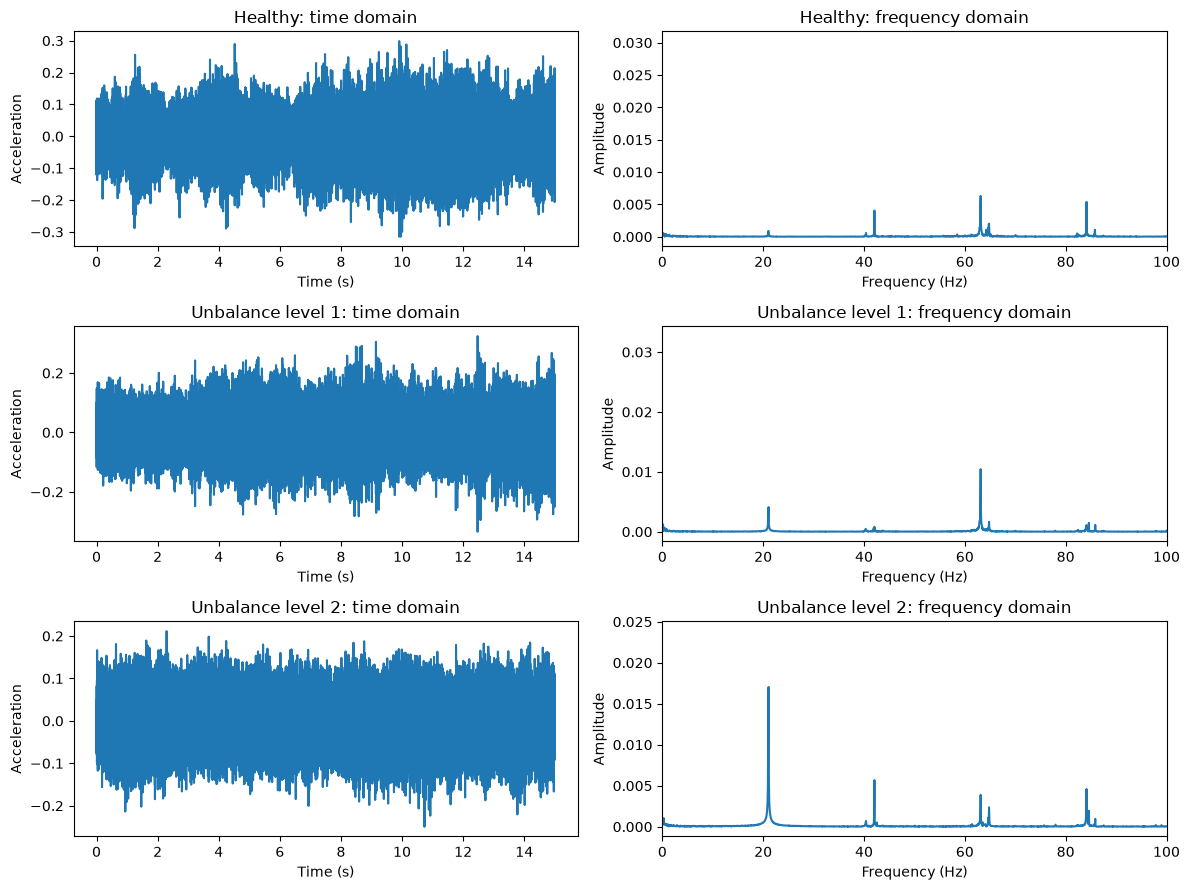

In [40]:
SAMPLING_RATE = 2560  # samples per second (Hz)

examples = [
    ("Healthy", healthy_signals[0]),
    ("Unbalance level 1", unbalance_1_signals[0]),
    ("Unbalance level 2", unbalance_2_signals[0]),
]

fig, axes = plt.subplots(3, 2, figsize=(12, 9))

for row, (label, signal) in enumerate(examples):
    time = np.arange(len(signal)) / SAMPLING_RATE
    frequencies = rfftfreq(len(signal), d=1 / SAMPLING_RATE)
    amplitudes = 2 * np.abs(rfft(signal)) / len(signal)

    axes[row, 0].plot(time, signal)
    axes[row, 0].set_title(f"{label}: time domain")
    axes[row, 0].set_xlabel("Time (s)")
    axes[row, 0].set_ylabel("Acceleration")

    axes[row, 1].plot(frequencies, amplitudes)
    axes[row, 1].set_title(f"{label}: frequency domain")
    axes[row, 1].set_xlabel("Frequency (Hz)")
    axes[row, 1].set_ylabel("Amplitude")
    axes[row, 1].set_xlim(0, 100)

fig.tight_layout()
plt.show()


## Extract features

Use raw signals without filtering. The first six features describe the time-domain shape and size. The remaining features measure peaks near 1X–4X (20–80 Hz) and their ratios to RMS. The ±0.5 Hz windows allow slight peak shifts. Kurtosis is 3 for a normal distribution.


In [41]:
SHAFT_FREQUENCY = 20  # Hz; 1X shaft rotation
HARMONIC_HALF_WIDTH = 0.5  # Hz


def harmonic_peak(frequencies, amplitudes, center):
    in_band = (frequencies >= center - HARMONIC_HALF_WIDTH) & (frequencies <= center + HARMONIC_HALF_WIDTH)
    return amplitudes[in_band].max()


def extract_features(signal):
    rms = np.sqrt(np.mean(signal**2))
    frequencies = rfftfreq(len(signal), d=1 / SAMPLING_RATE)
    amplitudes = 2 * np.abs(rfft(signal)) / len(signal)

    features = {
        "RMS": rms,
        "Peak-to-peak": np.ptp(signal),
        "Standard deviation": np.std(signal),
        "Kurtosis": kurtosis(signal, fisher=False),
        "Skewness": skew(signal),
        "Crest factor": np.max(np.abs(signal)) / rms,
    }

    for harmonic in range(1, 5):
        peak = harmonic_peak(frequencies, amplitudes, harmonic * SHAFT_FREQUENCY)
        features[f"{harmonic}X amplitude"] = peak
        features[f"{harmonic}X amplitude / RMS"] = peak / rms

    return features


healthy_features = pd.DataFrame([extract_features(signal) for signal in healthy_signals])
unbalance_1_features = pd.DataFrame([extract_features(signal) for signal in unbalance_1_signals])
unbalance_2_features = pd.DataFrame([extract_features(signal) for signal in unbalance_2_signals])
test_features = pd.DataFrame([extract_features(signal) for signal in test_signals])

training_features = pd.concat(
    [healthy_features, unbalance_1_features, unbalance_2_features], ignore_index=True
)
# Class labels: 0 = healthy, 1 = unbalance level 1, 2 = unbalance level 2.
training_labels = ([0] * len(healthy_signals)
                   + [1] * len(unbalance_1_signals)
                   + [2] * len(unbalance_2_signals))

print("Training features:", training_features.shape)
print("Test features:", test_features.shape)
display(training_features.head())


Training features: (60, 14)
Test features: (30, 14)


,RMS,Peak-to-peak,Standard deviation,Kurtosis,Skewness,Crest factor,1X amplitude,1X amplitude / RMS,2X amplitude,2X amplitude / RMS,3X amplitude,3X amplitude / RMS,4X amplitude,4X amplitude / RMS
0,0.066409,0.613653,0.066409,3.587488,-0.121979,4.743422,0.000062,0.000936,0.000579,0.008716,0.000205,0.003091,0.000038,0.000577
1,0.092479,0.688554,0.092479,2.938551,-0.062677,3.865084,0.000069,0.000743,0.000502,0.005431,0.000206,0.002231,0.000049,0.000526
2,0.070198,0.634557,0.070198,3.317284,0.044630,4.938712,0.000064,0.000910,0.000678,0.009664,0.000136,0.001932,0.000055,0.000782
3,0.076684,0.691687,0.076684,3.576105,-0.264599,5.104268,0.000075,0.000978,0.000661,0.008623,0.000139,0.001813,0.000062,0.000811
4,0.073982,0.837318,0.073979,4.483103,-0.248775,6.537908,0.000094,0.001271,0.000728,0.009845,0.000183,0.002472,0.000058,0.000778


## Multiclass Fisher scores

For each original feature, compare the variation **between** the three class means with the variation **within** the classes. A larger score suggests that feature separates the training classes more clearly on its own. This is a univariate ranking: it does not account for combinations of features, and it is not a significance test. PCA, by comparison, uses variance without the class labels.


In [42]:
class_groups = list(training_features.groupby(training_labels))
overall_mean = training_features.mean()

between_class = sum(
    len(group) * (group.mean() - overall_mean) ** 2
    for _, group in class_groups
)
within_class = sum(
    ((group - group.mean()) ** 2).sum()
    for _, group in class_groups
)

fisher_scores = (between_class / within_class).sort_values(ascending=False)
fisher_table = fisher_scores.rename("Fisher score").to_frame()
display(fisher_table)


,Fisher score
1X amplitude,51.329290
1X amplitude / RMS,24.479591
2X amplitude,4.528073
2X amplitude / RMS,3.602787
3X amplitude,0.511013
RMS,0.229602
Standard deviation,0.229531
3X amplitude / RMS,0.117967
4X amplitude / RMS,0.090963
4X amplitude,0.067844


## Principal component analysis

Standardize each feature using the training data, then fit PCA to the standardized training features. The chart shows how much variance each component explains and the cumulative fraction explained. We can choose the number of components after inspecting it.


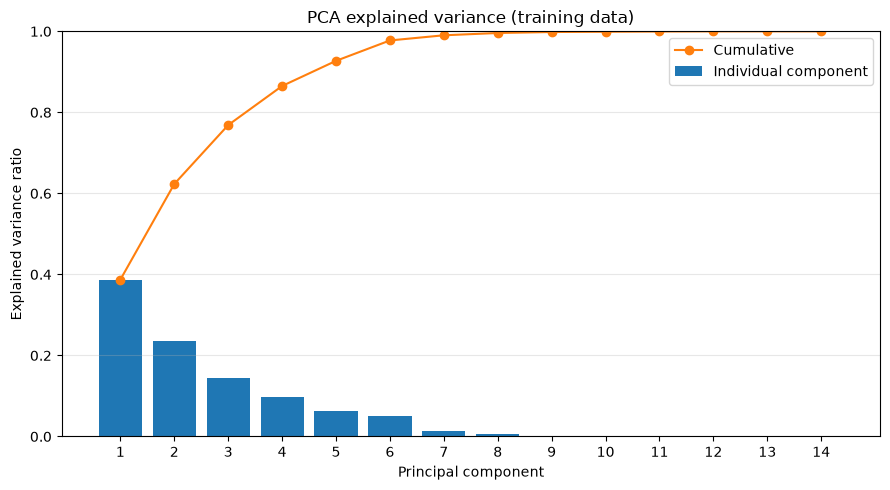

Cumulative explained variance:
 1 components: 38.7%
 2 components: 62.3%
 3 components: 76.9%
 4 components: 86.5%
 5 components: 92.7%
 6 components: 97.8%
 7 components: 99.0%
 8 components: 99.6%
 9 components: 99.8%
10 components: 99.9%
11 components: 100.0%
12 components: 100.0%
13 components: 100.0%
14 components: 100.0%


In [43]:
scaler = StandardScaler()
scaled_training_features = scaler.fit_transform(training_features)

pca = PCA()
pca.fit(scaled_training_features)

component_numbers = np.arange(1, len(pca.explained_variance_ratio_) + 1)
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(9, 5))
plt.bar(component_numbers, explained_variance, label="Individual component")
plt.plot(component_numbers, cumulative_variance, marker="o", color="tab:orange", label="Cumulative")
plt.xticks(component_numbers)
plt.ylim(0, 1)
plt.xlabel("Principal component")
plt.ylabel("Explained variance ratio")
plt.title("PCA explained variance (training data)")
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print("Cumulative explained variance:")
for number, fraction in zip(component_numbers, cumulative_variance):
    print(f"{number:2d} components: {fraction:.1%}")


## Keep enough principal components

Choose the smallest number of components whose cumulative explained variance reaches the threshold. The scaler and PCA were fitted using training data only; apply those same fitted transforms to the test features.


In [44]:
VARIANCE_THRESHOLD = 0.99
number_of_components = np.searchsorted(cumulative_variance, VARIANCE_THRESHOLD) + 1

training_pcs = pca.transform(scaled_training_features)[:, :number_of_components]
scaled_test_features = scaler.transform(test_features)
test_pcs = pca.transform(scaled_test_features)[:, :number_of_components]

print(f"Selected {number_of_components} components")
print(f"Cumulative explained variance: {cumulative_variance[number_of_components - 1]:.4%}")
print("Training PCA shape:", training_pcs.shape)
print("Test PCA shape:", test_pcs.shape)


Selected 7 components
Cumulative explained variance: 99.0235%
Training PCA shape: (60, 7)
Test PCA shape: (30, 7)


## Compare PCA and LDA on training data

PCA seeks directions with high overall variance; LDA uses the known classes to seek directions that separate them. Three classes allow at most two LDA components. Compare the same linear SVM after each method on repeated, stratified training folds. Each pipeline refits scaling and dimensionality reduction within each fold. The 2D plots help visualize separation, but the PCA plot shows only two of the seven PCs used by its SVM.


In [ ]:
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)
cv_splits = list(cv.split(training_features, training_labels))

pca_pipeline = make_pipeline(
    StandardScaler(), PCA(n_components=VARIANCE_THRESHOLD, svd_solver="full"),
    SVC(kernel="linear", C=1.0)
)
lda_pipeline = make_pipeline(
    StandardScaler(), LinearDiscriminantAnalysis(n_components=2),
    SVC(kernel="linear", C=1.0)
)

pca_scores = cross_val_score(pca_pipeline, training_features, training_labels, cv=cv_splits)
lda_scores = cross_val_score(lda_pipeline, training_features, training_labels, cv=cv_splits)

print(f"PCA + SVM: {pca_scores.mean():.1%} mean validation accuracy")
print(f"LDA + SVM: {lda_scores.mean():.1%} mean validation accuracy")
print(f"LDA better / equal / worse across folds: "
      f"{np.sum(lda_scores > pca_scores)} / {np.sum(lda_scores == pca_scores)} / {np.sum(lda_scores < pca_scores)}")

# Fit LDA on all training signals only, for visualization and final prediction.
lda = LinearDiscriminantAnalysis(n_components=2)
training_lda = lda.fit_transform(scaled_training_features, training_labels)
test_lda = lda.transform(scaled_test_features)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for class_number, class_name in [(0, "Healthy"), (1, "Unbalance 1"), (2, "Unbalance 2")]:
    in_class = np.array(training_labels) == class_number
    axes[0].scatter(training_pcs[in_class, 0], training_pcs[in_class, 1], label=class_name)
    axes[1].scatter(training_lda[in_class, 0], training_lda[in_class, 1], label=class_name)
axes[0].set(title="PCA: first two components", xlabel="PC1", ylabel="PC2")
axes[1].set(title="LDA: both components", xlabel="LD1", ylabel="LD2")
axes[1].legend()
fig.tight_layout()
plt.show()


## Linear SVM predictions with LDA

Fit a linear SVM to the two LDA components and the known training labels. Predict each test signal without using its answer label. Class numbers are 0 = healthy, 1 = unbalance level 1, and 2 = unbalance level 2.


In [45]:
svm_model = SVC(kernel="linear", C=1.0)
svm_model.fit(training_lda, training_labels)

test_predictions = svm_model.predict(test_lda)
test_results = pd.DataFrame({
    "Test file": [path.name for path in test_files],
    "Predicted class": test_predictions,
})

display(test_results)
print("Predictions by class:")
print(test_results["Predicted class"].value_counts().sort_index())


,Test file,Predicted class
0,Data Mar-26-14 Time 1533-21.txt,0
1,Data Mar-26-14 Time 1534-22.txt,0
2,Data Mar-26-14 Time 1540-23.txt,0
3,Data Mar-26-14 Time 1540-24.txt,0
4,Data Mar-26-14 Time 1540-25.txt,0
5,Data Mar-26-14 Time 1543-26.txt,0
6,Data Mar-26-14 Time 1543-27.txt,0
7,Data Mar-26-14 Time 1543-28.txt,0
8,Data Mar-26-14 Time 1544-29.txt,0
9,Data Mar-26-14 Time 1544-30.txt,0


Predictions by class:
Predicted class
0    10
1    11
2     9
Name: count, dtype: int64


## Evaluate with the labels in the assignment

The PDF lists 10 healthy, 10 level 1, and 10 level 2 test signals. In `test_files`, the filenames sort into those same three consecutive groups. Assign those known labels only now, after making predictions. Rows in the confusion matrix are actual classes; columns are predicted classes.


Test accuracy: 96.7% (29/30 correct)


,Test file,Predicted class,Actual class
0,Data Mar-26-14 Time 1533-21.txt,0,0
1,Data Mar-26-14 Time 1534-22.txt,0,0
2,Data Mar-26-14 Time 1540-23.txt,0,0
3,Data Mar-26-14 Time 1540-24.txt,0,0
4,Data Mar-26-14 Time 1540-25.txt,0,0
5,Data Mar-26-14 Time 1543-26.txt,0,0
6,Data Mar-26-14 Time 1543-27.txt,0,0
7,Data Mar-26-14 Time 1543-28.txt,0,0
8,Data Mar-26-14 Time 1544-29.txt,0,0
9,Data Mar-26-14 Time 1544-30.txt,0,0


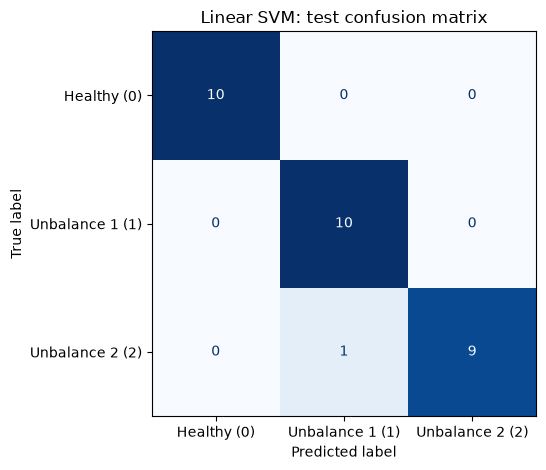

In [46]:
# The sorted test filenames appear in the PDF's class order: 10 healthy, 10 level 1, 10 level 2.
test_labels = np.array([0] * 10 + [1] * 10 + [2] * 10)
assert len(test_labels) == len(test_files)

test_results["Actual class"] = test_labels
confusion = confusion_matrix(test_labels, test_predictions, labels=[0, 1, 2])
accuracy = accuracy_score(test_labels, test_predictions)

print(f"Test accuracy: {accuracy:.1%} ({np.trace(confusion)}/{len(test_labels)} correct)")
display(test_results)

class_names = ["Healthy (0)", "Unbalance 1 (1)", "Unbalance 2 (2)"]
ConfusionMatrixDisplay(confusion_matrix=confusion, display_labels=class_names).plot(
    cmap="Blues", colorbar=False
)
plt.title("LDA + linear SVM: test confusion matrix")
plt.tight_layout()
plt.show()
